# 2 · The dataset: BDD-style frames in Lance, queried with Daft

The dataset lives in **Lance** — a columnar, zero-copy, versioned format built
for ML. Each row is one frame: an image plus its `weather` / `timeofday` /
`scene` attributes and its `split`. We query it with **Daft**, a distributed
multimodal dataframe, exactly as we would the real BDD100K.

In [1]:
import sys, os, warnings
from pathlib import Path
warnings.filterwarnings("ignore")
sys.path.insert(0, str(Path.cwd().parent))   # make `harness` importable
import matplotlib
matplotlib.use("Agg")
import numpy as np
import matplotlib.pyplot as plt

from harness.data import make_synthetic_dataset, DatasetSpec, load_split, class_names

DATA = Path("../data/bdd-tiny.lance")
if not DATA.exists():
    print("building a small bdd-tiny ...")
    make_synthetic_dataset(DATA, DatasetSpec(n=3000, seed=7))
print("dataset:", DATA)

dataset: ../data/bdd-tiny.lance


### The Lance dataset and its schema

In [2]:
import lance
ds = lance.dataset(str(DATA))
print("rows:", ds.count_rows())
print(ds.schema)

rows: 3000
id: int64
image: fixed_size_list<item: uint8>[3072]
  child 0, item: uint8
label: int64
timeofday: string
weather: string
scene: string
split: string


### Query attributes with Daft

In [3]:
import daft
# read straight from the Lance table into a Daft dataframe
df = daft.from_arrow(lance.dataset(str(DATA)).to_table().drop(["image"]))
counts = (df.groupby("split", "weather").agg(daft.col("id").count().alias("n"))
            .sort(["split", "weather"]))
counts.show(20)

splitString,weatherString,nUInt64
test,clear,150
test,foggy,45
test,overcast,99
test,rainy,83
test,snowy,73
train,clear,670
train,foggy,196
train,overcast,477
train,rainy,392
train,snowy,365


### Class balance and the rare fog slice

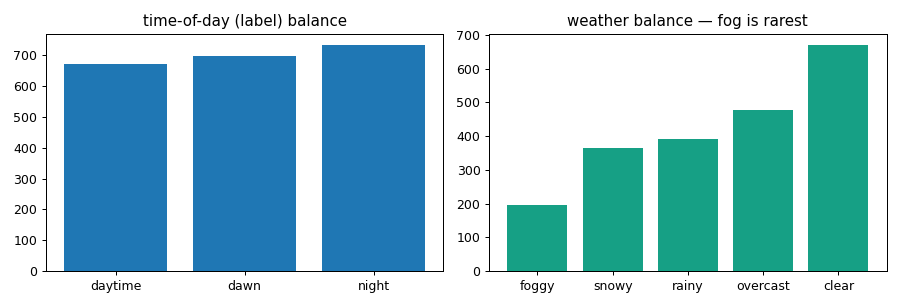

In [4]:
import collections
_, y, meta = load_split(DATA, "train")
wc = collections.Counter(meta["weather"])
fig, (a, b) = plt.subplots(1, 2, figsize=(10, 3.4))
a.bar(list(class_names()), np.bincount(y)); a.set_title("time-of-day (label) balance")
ws = sorted(wc, key=wc.get)
b.bar(ws, [wc[w] for w in ws], color="#16a085"); b.set_title("weather balance — fog is rarest")
fig.tight_layout(); fig.savefig("fig_02_balance.png", dpi=90); plt.close(fig)
from IPython.display import Image; Image("fig_02_balance.png")

### Why fog is hard: brightness is corrupted, only weak colour survives

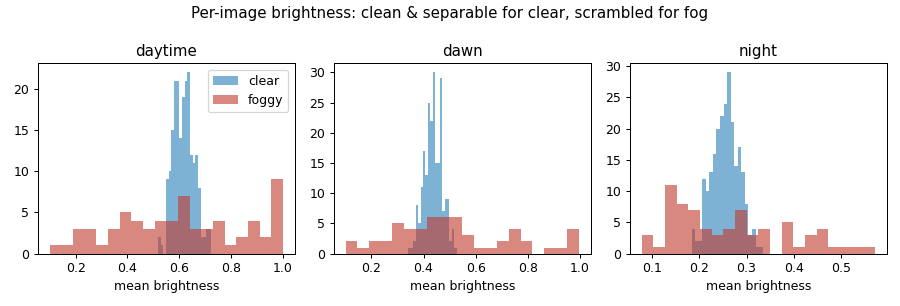

In [5]:
x, y, meta = load_split(DATA, "train")
fig, axes = plt.subplots(1, 3, figsize=(10, 3.4))
for ax, cls in zip(axes, range(3)):
    for w, c in [("clear", "#2980b9"), ("foggy", "#c0392b")]:
        sel = (y == cls) & (meta["weather"] == w)
        ax.hist(x[sel].mean(axis=(1, 2, 3)), bins=20, alpha=0.6, label=w, color=c)
    ax.set_title(class_names()[cls]); ax.set_xlabel("mean brightness")
axes[0].legend()
fig.suptitle("Per-image brightness: clean & separable for clear, scrambled for fog")
fig.tight_layout(); fig.savefig("fig_02_bright.png", dpi=90); plt.close(fig)
from IPython.display import Image; Image("fig_02_bright.png")

Brightness cleanly separates time-of-day under **clear** weather, but under
**fog** the haze scrambles it — the histograms overlap. The only surviving cue
is a faint colour tint, which the next chapters teach the model to use.